# Component Summation

Aggregate projections from the per-component notebooks into total GMSL.

**Components summed:** Thermosteric (ocean), Glaciers, Greenland, Antarctic Peninsula, WAIS, TWS

**Excluded:** EAIS (IMBIE record too short and noisy to constrain a reliable
projection; the contribution is small and negative, so exclusion is conservative).

**Method:** Load MC sample ensembles from `component_results.h5`, sum
sample-by-sample to preserve correlations within each draw, then compute
percentiles on the total.  TWS is loaded separately from IPCC AR6
`landwaterstorage` and converted to synthetic MC samples.

**Sections:**
1. Load all component projections
2. Sum components → total GMSL
3. Diagnostics: budget closure, hindcasts, residual attribution
4. Summary table (2050, 2100, 2150)
5. Projection fan plots
6. Component stack & variance decomposition
7. IPCC AR6 comparison

In [1]:
import sys, os
import json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
from numpy.polynomial.polynomial import polyfit
from pathlib import Path
from scipy.stats import norm

sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')

sys.path.insert(0, '.')
from component_io import (
    load_all_projections, load_component,
    N_SAMPLES, PROJ_SSPS, PROJ_YEARS, DEFAULT_H5_PATH,
)
from component_projections import (
    read_ipcc_component_nc, ipcc_extract,
    get_our_stats, get_ipcc_stats, stats_dict,
)
from component_analysis import compute_variance_fractions
from component_plotting import (
    SSP_COLORS, COMP_COLORS,
    plot_component_projections,
    plot_variance_decomposition,
)
from slr_projections import (
    project_gmsl_state_ensemble,
    project_component_level_ensemble,
)
from bayesian_models import fit_satellite_era_quadratic
from slr_forecast.config import (
    BASELINE_YEAR, GT_TO_M_SLE, Z_94, Z_90,
    IPCC_CONFIDENCE, IPCC_REF_PERIOD, SAT_ERA_START,
)
from slr_forecast import M_TO_MM

# ── Paths ──
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'
H5_PATH = str(DEFAULT_H5_PATH)

# ── MC parameters ──
N_MC = 2000
SEED = 42

# ── Display names for components (HDF5 key → label) ──
# EAIS excluded: IMBIE record too short and noisy to constrain a trend;
# the ~-19 mm contribution is not supported by observations.
COMP_LABELS = {
    'ocean': 'Thermosteric',
    'glacier': 'Glaciers',
    'greenland': 'Greenland',
    # 'eais': 'EAIS',
    'apeninsula': 'Peninsula',
    'wais': 'WAIS',
    'tws': 'TWS',
}

# SSP name → IPCC code
SSP_TO_CODE = {
    'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

# ── Derived constants ──
comp_order = list(COMP_LABELS.values())
MILESTONE_YEARS = [2050, 2100, 2150]


## 1. Load All Component Projections

In [2]:
# Load projection ensembles for all components
proj_years, all_proj = load_all_projections()

available = sorted(all_proj.keys())
print(f'Loaded components: {available}')
print(f'Projection years: {proj_years[0]:.0f}–{proj_years[-1]:.0f} ({len(proj_years)} pts)')

# Check SSP coverage per component
for comp in available:
    ssps = sorted(all_proj[comp].keys())
    has_samples = all('samples' in all_proj[comp][s] for s in ssps)
    print(f'  {comp:12s}  SSPs: {", ".join(ssps)}  samples: {has_samples}')
# Rebase all components from storage baseline (2005) to BASELINE_YEAR
idx_rebase = np.argmin(np.abs(proj_years - BASELINE_YEAR))
for comp in all_proj:
    for ssp in all_proj[comp]:
        d = all_proj[comp][ssp]
        if 'samples' in d:
            shift = d['samples'][:, idx_rebase:idx_rebase+1]
            d['samples'] = d['samples'] - shift
            d['median']  = np.median(d['samples'], axis=0)
            d['p5']  = np.percentile(d['samples'], 5, axis=0)
            d['p17'] = np.percentile(d['samples'], 17, axis=0)
            d['p83'] = np.percentile(d['samples'], 83, axis=0)
            d['p95'] = np.percentile(d['samples'], 95, axis=0)
print(f'Rebased all components to {BASELINE_YEAR:.0f}')


Loaded components: ['apeninsula', 'eais', 'glacier', 'greenland', 'ocean', 'wais']
Projection years: 1950–2150 (201 pts)
  apeninsula    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  eais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  glacier       SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  greenland     SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  ocean         SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  wais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True


Rebased all components to 2000


In [3]:
# ── Load IPCC TWS (land water storage) and generate synthetic MC samples ──
# TWS is not modeled independently; we adopt the IPCC AR6 projections
# directly.  IPCC provides quantiles, so we fit a normal distribution
# at each time step and draw N_SAMPLES to enable sample-level summation.

tws_proj = {}
for ssp in PROJ_SSPS:
    code = SSP_TO_CODE[ssp]
    data = read_ipcc_component_nc(CONF_BASE, IPCC_CONFIDENCE, code,
                                  'landwaterstorage')
    if data is None:
        print(f'  TWS: {ssp} not found — skipping')
        continue

    ie = ipcc_extract(data, quantiles_target=(0.05, 0.17, 0.5, 0.83, 0.95))
    ipcc_years = ie['years']
    q50 = ie['q50']           # mm
    q05 = ie['q05']
    q95 = ie['q95']
    q17 = ie['q17']
    q83 = ie['q83']

    # Approximate sigma from 90% CI: (q95 - q05) / (2 * Z_90)
    sigma_mm = (q95 - q05) / (2 * Z_90)
    sigma_mm = np.maximum(sigma_mm, 0.1)  # floor to avoid zero

    # Draw MC samples at IPCC time points, then interpolate onto PROJ_YEARS
    rng_tws = np.random.default_rng(seed=777)
    n_ipcc = len(ipcc_years)
    raw_samples_mm = np.zeros((N_SAMPLES, n_ipcc))
    for j in range(n_ipcc):
        raw_samples_mm[:, j] = rng_tws.normal(q50[j], sigma_mm[j], N_SAMPLES)

    # Interpolate onto PROJ_YEARS (meters)
    samples_m = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for i in range(N_SAMPLES):
        samples_m[i] = np.interp(PROJ_YEARS, ipcc_years,
                                  raw_samples_mm[i] / M_TO_MM)

    tws_proj[ssp] = {
        'samples': samples_m,
        'median': np.median(samples_m, axis=0),
        'p5': np.percentile(samples_m, 5, axis=0),
        'p17': np.percentile(samples_m, 17, axis=0),
        'p83': np.percentile(samples_m, 83, axis=0),
        'p95': np.percentile(samples_m, 95, axis=0),
    }

# Inject into all_proj so it participates in the standard summation
all_proj['tws'] = tws_proj

# Rebase TWS to BASELINE_YEAR (same as other components)
idx_rebase = np.argmin(np.abs(PROJ_YEARS - BASELINE_YEAR))
for ssp in tws_proj:
    d = tws_proj[ssp]
    shift = d['samples'][:, idx_rebase:idx_rebase+1]
    d['samples'] = d['samples'] - shift
    d['median']  = np.median(d['samples'], axis=0)
    d['p5']  = np.percentile(d['samples'], 5, axis=0)
    d['p17'] = np.percentile(d['samples'], 17, axis=0)
    d['p83'] = np.percentile(d['samples'], 83, axis=0)
    d['p95'] = np.percentile(d['samples'], 95, axis=0)

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
for ssp in PROJ_SSPS:
    if ssp in tws_proj:
        med = tws_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = tws_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = tws_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  TWS {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

  TWS SSP1-2.6 at 2100: 29 [8, 50] mm
  TWS SSP2-4.5 at 2100: 30 [7, 53] mm
  TWS SSP3-7.0 at 2100: 35 [9, 61] mm
  TWS SSP5-8.5 at 2100: 29 [8, 50] mm


## 2. Sum Components → Total GMSL

In [4]:
# ── Build comp_projections in the {ssp: {Label: dict}} layout ──
# This is the format expected by plot_component_projections and
# compute_variance_fractions.
comp_projections = {}

for ssp in PROJ_SSPS:
    comp_projections[ssp] = {}

    # Per-component entries (relabelled, truncated to N_SAMPLES)
    for hdf_key, label in COMP_LABELS.items():
        if hdf_key in all_proj and ssp in all_proj[hdf_key]:
            entry = all_proj[hdf_key][ssp]
            comp_projections[ssp][label] = {
                k: v[:N_SAMPLES] if hasattr(v, '__len__') and len(v.shape) > 1 else v
                for k, v in entry.items()
            }

    # Total: sum MC samples across all available components
    # Truncate to N_SAMPLES (WAIS has 10k, everything else 2k)
    total_samples = np.zeros((N_SAMPLES, len(proj_years)))
    n_comps_summed = 0
    for hdf_key in COMP_LABELS:
        if hdf_key not in all_proj or ssp not in all_proj[hdf_key]:
            continue
        s = all_proj[hdf_key][ssp]['samples'][:N_SAMPLES]
        total_samples += s
        n_comps_summed += 1

    comp_projections[ssp]['Total_sum'] = {
        'samples': total_samples,
        'median': np.median(total_samples, axis=0),
        'p5': np.percentile(total_samples, 5, axis=0),
        'p17': np.percentile(total_samples, 17, axis=0),
        'p83': np.percentile(total_samples, 83, axis=0),
        'p95': np.percentile(total_samples, 95, axis=0),
    }

print(f'Summed {n_comps_summed} components for each SSP')

Summed 6 components for each SSP


## 3. Diagnostics: Budget Closure & Hindcasts

Core diagnostics comparing our GMST-forced component sum against
observed GMSL (NASA altimetry, Frederikse, Dangendorf):

1. **Component hindcasts vs Frederikse** — per-component level comparison
2. **GMST-forced total hindcast** — all 7 components summed vs GMSL observations
3. **Residual analysis (Option 1)** — rate-and-state minus component sum,
   plus GMSL-rate vs GMST phase-space diagram

Additional diagnostics (baseline checks, rate tables, budget closure)
are in the addendum cells below, gated by `RUN_ADDENDUM = True`.

In [5]:
# ── Load observation data for diagnostics ──

_ANY_SSP = PROJ_SSPS[0]  # hindcast is SSP-independent

H5_OBS = '../data/processed/slr_processed_data.h5'
with pd.HDFStore(H5_OBS, 'r') as store:
    df_nasa = store['/harmonized/df_nasa_gmsl_h']
    df_fred = store['/harmonized/df_frederikse_h']
    df_berk = store['/harmonized/df_berkeley_h']
    df_dang = store['/harmonized/df_dangendorf_h']

# ── NASA GMSL: rebase to BASELINE_YEAR ──
nasa_time = df_nasa['decimal_year'].values
nasa_gmsl = df_nasa['gmsl'].values  # meters
nasa_gmsl_sigma = df_nasa['gmsl_sigma'].values
idx_bl = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl[idx_bl]

# ── Frederikse: rebase all columns to BASELINE_YEAR ──
fred_year = df_fred['year'].values.astype(float)
idx_fred_bl = np.argmin(np.abs(fred_year - BASELINE_YEAR))

fred_gmsl = df_fred['gmsl'].values - df_fred['gmsl'].values[idx_fred_bl]
fred_sum  = df_fred['sum_contributors'].values - df_fred['sum_contributors'].values[idx_fred_bl]
fred_steric = df_fred['steric'].values - df_fred['steric'].values[idx_fred_bl]
fred_glaciers = df_fred['glaciers'].values - df_fred['glaciers'].values[idx_fred_bl]
fred_greenland = df_fred['greenland'].values - df_fred['greenland'].values[idx_fred_bl]
fred_antarctica = df_fred['antarctica'].values - df_fred['antarctica'].values[idx_fred_bl]
fred_tws = df_fred['tws'].values - df_fred['tws'].values[idx_fred_bl]

# ── Dangendorf: rebase to BASELINE_YEAR ──
dang_time = df_dang['decimal_year'].values
dang_gmsl = df_dang['gmsl'].values
idx_dang_bl = np.argmin(np.abs(dang_time - BASELINE_YEAR))
dang_gmsl_rb = dang_gmsl - dang_gmsl[idx_dang_bl]

# ── Berkeley Earth monthly GMST (from 1850 for ODE spin-up) ──
berk_time = np.array([t.year + (t.month - 0.5) / 12 for t in df_berk.index])
berk_temp = df_berk['temperature'].values
mask_1850 = berk_time >= 1850
T_monthly = berk_temp[mask_1850]
t_monthly = berk_time[mask_1850]

berk_annual = df_berk[['temperature']].resample('YS').mean()
berk_annual['decimal_year'] = berk_annual.index.year + 0.5

# ── Per-component observations from component_results.h5 ──
comp_obs = {}
for comp_name in list(COMP_LABELS.keys()):
    if comp_name == 'tws':
        continue
    comp_obs[comp_name] = load_component(comp_name)

print(f'NASA GMSL: {nasa_time[0]:.1f}\u2013{nasa_time[-1]:.1f}')
print(f'Frederikse: {fred_year[0]:.0f}\u2013{fred_year[-1]:.0f}')
print(f'Dangendorf: {dang_time[0]:.0f}\u2013{dang_time[-1]:.0f}')
print(f'Berkeley Earth: {berk_time[0]:.0f}\u2013{berk_time[-1]:.0f}')
print(f'Component obs loaded: {sorted(comp_obs.keys())}')


NASA GMSL: 1993.0–2025.3
Frederikse: 1900–2018
Dangendorf: 1900–2021
Berkeley Earth: 1850–2025
Component obs loaded: ['apeninsula', 'glacier', 'greenland', 'ocean', 'wais']


Ocean (stored): 1950–2025, (2000, 76)
Glacier: 1950–2025
Greenland (stored): 1950–2025
WAIS (wais_2k): 1950–2025, shape=(2000, 76)
TWS (Frederikse): 1900–2018, extrapolated flat beyond 2018


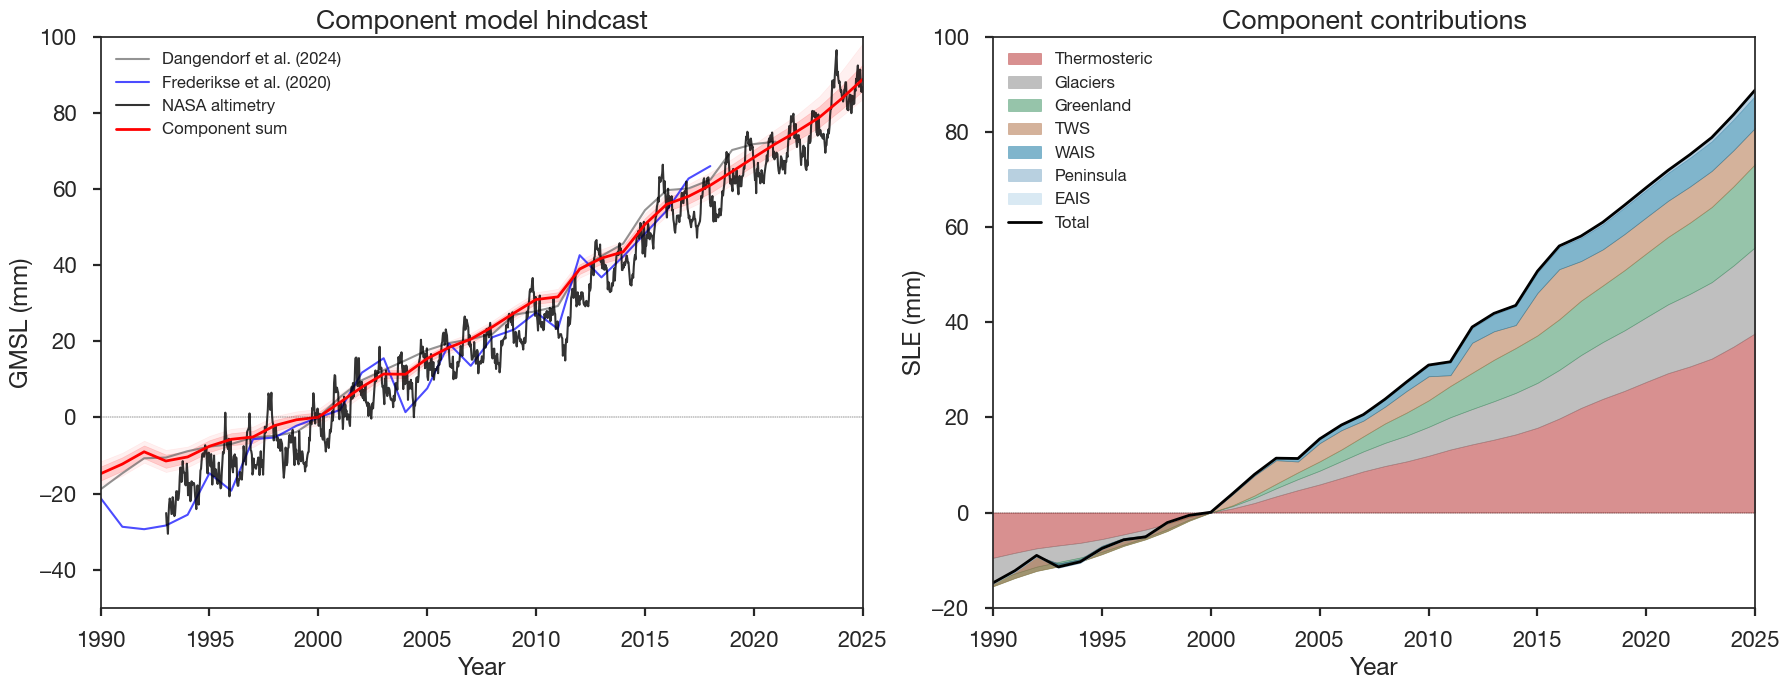


Budget closure by epoch (T-forced hindcast, no EAIS):
  Epoch             NASA (mm/yr)    Sum (mm/yr)  Resid (mm/yr)    Closure
  --------------- -------------- -------------- -------------- ----------
  1993–2025                 3.29           3.21           0.09      97.4%
  2000–2025                 3.49           3.53          -0.04     101.0%
  2010–2025                 4.11           3.83           0.28      93.3%

  Component        Trend (mm/yr)   Share of sum
  --------------- -------------- --------------
  Thermosteric              1.35          42.1%
  Glaciers                  0.67          20.8%
  Greenland                 0.62          19.3%
  WAIS                      0.26           8.1%
  Peninsula                 0.04           1.1%
  TWS                       0.27           8.3%
  Sum                       3.20

  Year         NASA      Sum    Resid
  -------- -------- -------- --------
  2000         -0.8      0.1     -0.8
  2005         13.7     15.6     -1.9
  20

In [6]:
# ── Diagnostic 6: GMST-forced hindcast vs observed GMSL ──
# Re-run T-forced component models with observed Berkeley Earth GMST
# and compare the total against Frederikse, Dangendorf, and NASA GMSL.
#
# Components re-run from posteriors: glacier, EAIS, peninsula
# Components using stored projections: ocean (hybrid NOAA+IPCC),
#   WAIS (scenario-based)
# TWS: Frederikse (2020) observations with MC sampling from sigma

# ====== USER FLAGS ======
HIND_START = 1950   # left edge of plot
HIND_END   = 2025   # right edge of plot
# ========================

hind_years = np.arange(HIND_START, HIND_END + 1, dtype=float)

# ── Load posteriors from HDF5 (non-ocean components) ──
with h5py.File(H5_PATH, 'r') as f:
    gl_post = f['glacier/posteriors/posterior_samples'][:]
    gl_H0 = f['glacier/posteriors/H0_posterior'][:]
    gl_order = int(f['glacier'].attrs['model_order'])

    ea_post = f['eais/posteriors/posterior_samples'][:]
    ea_H0 = f['eais/posteriors/H0_posterior'][:]
    ea_order = int(f['eais'].attrs['model_order'])

    ap_post = f['apeninsula/posteriors/posterior_samples'][:]
    ap_H0 = f['apeninsula/posteriors/H0_posterior'][:]
    ap_order = int(f['apeninsula'].attrs['model_order'])

# ── Ocean: load stored samples (hybrid NOAA+IPCC, no ODE re-run) ──
stored_oc = all_proj['ocean'][_ANY_SSP]
ocean_samples = stored_oc['samples']
n_oc = min(N_MC, ocean_samples.shape[0])
ocean_samp_interp = np.zeros((n_oc, len(hind_years)))
for k in range(n_oc):
    ocean_samp_interp[k] = np.interp(hind_years, proj_years, ocean_samples[k])
ocean_med_interp = np.interp(hind_years, proj_years, stored_oc['median'])
print(f'Ocean (stored): {hind_years[0]:.0f}–{hind_years[-1]:.0f}, '
      f'{ocean_samp_interp.shape}')

# ── Glacier: level-space DOLS ──
glacier_hind = project_component_level_ensemble(
    posterior_samples=gl_post, H0_samples=gl_H0,
    temperature_monthly=T_monthly, time_monthly=t_monthly,
    projection_times=hind_years, baseline_year=BASELINE_YEAR,
    n_samples=N_MC, order=gl_order, seed=SEED + 1,
)
print(f'Glacier: {hind_years[0]:.0f}–{hind_years[-1]:.0f}')

# ── EAIS ──
eais_hind = project_component_level_ensemble(
    posterior_samples=ea_post, H0_samples=ea_H0,
    temperature_monthly=T_monthly, time_monthly=t_monthly,
    projection_times=hind_years, baseline_year=BASELINE_YEAR,
    n_samples=N_MC, order=ea_order, seed=SEED + 2,
)

# ── Peninsula ──
apen_hind = project_component_level_ensemble(
    posterior_samples=ap_post, H0_samples=ap_H0,
    temperature_monthly=T_monthly, time_monthly=t_monthly,
    projection_times=hind_years, baseline_year=BASELINE_YEAR,
    n_samples=N_MC, order=ap_order, seed=SEED + 3,
)

# ── Stored projections for components that can't be trivially re-run ──
# Pre-baseline is historical-forced (SSP-independent); SSPs barely
# diverge over this short window.  Pick any SSP as carrier.
_ANY_SSP = PROJ_SSPS[0]

def _interp_stored(comp_name):
    """Interpolate stored MC samples onto hind_years."""
    stored = all_proj[comp_name][_ANY_SSP]
    samp_full = stored['samples']
    samp = np.zeros((samp_full.shape[0], len(hind_years)))
    for k in range(samp_full.shape[0]):
        samp[k] = np.interp(hind_years, proj_years, samp_full[k])
    med = np.interp(hind_years, proj_years, stored['median'])
    return samp, med

gr_samples, gr_med = _interp_stored('greenland')
print(f'Greenland (stored): {hind_years[0]:.0f}–{hind_years[-1]:.0f}')

# WAIS: use wais_2k (N_SAMPLES=2000) not wais/projections (10000)
with h5py.File(H5_PATH, 'r') as _hf:
    _wais_samp = _hf['wais_2k/full_samples'][:]  # (2000, 201)
    _wais_yr = _hf['wais_2k/years'][:]
wais_samples = np.zeros((_wais_samp.shape[0], len(hind_years)))
for k in range(_wais_samp.shape[0]):
    wais_samples[k] = np.interp(hind_years, _wais_yr, _wais_samp[k])
wais_med = np.median(wais_samples, axis=0)
print(f'WAIS (wais_2k): {hind_years[0]:.0f}–{hind_years[-1]:.0f}, shape={wais_samples.shape}')

# ── TWS: Frederikse (2020) observations ──
# Use observed TWS (1900–2018) with MC samples drawn from sigma,
# Extrapolate flat beyond 2018 (last observation).
fred_tws_raw = df_fred['tws'].values       # meters
fred_tws_sig = df_fred['tws_sigma'].values  # meters
fred_tws_rb = df_fred['tws'].values - df_fred['tws'].values[idx_fred_bl]

rng_tws = np.random.default_rng(SEED + 5)
tws_samples = np.zeros((N_MC, len(hind_years)))
for k in range(N_MC):
    # Draw perturbed TWS on Frederikse years, then interpolate to hind_years
    tws_draw = fred_tws_rb + rng_tws.normal(0, fred_tws_sig)
    tws_samples[k] = np.interp(hind_years, fred_year, tws_draw)

tws_med = np.interp(hind_years, fred_year, fred_tws_rb)
print(f'TWS (Frederikse): {fred_year[0]:.0f}–{fred_year[-1]:.0f}, '
      f'extrapolated flat beyond 2018')

# ── Sum all components ──
# Interpolate ocean samples onto hind_years

n = min(n_oc, glacier_hind['samples'].shape[0],
        gr_samples.shape[0], wais_samples.shape[0], tws_samples.shape[0])
total_samples = (ocean_samp_interp[:n]
                 + glacier_hind['samples'][:n]
                 + eais_hind['samples'][:n]
                 + apen_hind['samples'][:n]
                 + gr_samples[:n]
                 + wais_samples[:n]
                 + tws_samples[:n])

total_med = np.median(total_samples, axis=0)
total_p5 = np.percentile(total_samples, 5, axis=0)
total_p17 = np.percentile(total_samples, 17, axis=0)
total_p83 = np.percentile(total_samples, 83, axis=0)
total_p95 = np.percentile(total_samples, 95, axis=0)

# ── Total without EAIS ──
total_no_eais = (ocean_samp_interp[:n]
                 + glacier_hind['samples'][:n]
                 + apen_hind['samples'][:n]
                 + gr_samples[:n]
                 + wais_samples[:n]
                 + tws_samples[:n])

total_no_eais_med = np.median(total_no_eais, axis=0)


# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel (a): Total hindcast vs observations
ax = axes[0]
dm = (dang_time >= HIND_START) & (dang_time <= HIND_END)
ax.plot(dang_time[dm], dang_gmsl_rb[dm] * M_TO_MM, color='0.4', lw=1.5,
        alpha=0.7, label='Dangendorf et al. (2024)')
fm = (fred_year >= HIND_START) & (fred_year <= HIND_END)
ax.plot(fred_year[fm], fred_gmsl[fm] * M_TO_MM, 'b-', lw=1.5, alpha=0.7,
        label='Frederikse et al. (2020)')
nm = (nasa_time >= max(1993, HIND_START)) & (nasa_time <= HIND_END)
ax.plot(nasa_time[nm], nasa_gmsl_rb[nm] * M_TO_MM, 'k-', lw=1.5, alpha=0.8,
        label='NASA altimetry')

ax.plot(hind_years, total_med * M_TO_MM, 'r-', lw=2,
        label='Component sum')
ax.fill_between(hind_years, total_p17 * M_TO_MM, total_p83 * M_TO_MM,
                color='r', alpha=0.15)
ax.fill_between(hind_years, total_p5 * M_TO_MM, total_p95 * M_TO_MM,
                color='r', alpha=0.06)


ax.set_xlim(1990, 2025)
ax.set_ylim(-50,100)
ax.set_xlabel('Year')
ax.set_ylabel(f'GMSL (mm)')
ax.set_title('Component model hindcast')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=12, loc='upper left')

# Panel (b): Stacked per-component contributions
ax = axes[1]
STACK_ALPHA = 0.5

# Arete-derived component colors
# Component colors imported from component_plotting.COMP_COLORS

# Order components from largest to smallest contribution at end of record
stack_components = [
    ('Thermosteric', ocean_med_interp * M_TO_MM),
    ('Glaciers', glacier_hind['median'] * M_TO_MM),
    ('Greenland', gr_med * M_TO_MM),
    ('TWS', tws_med * M_TO_MM),
    ('WAIS', wais_med * M_TO_MM),
    ('Peninsula', apen_hind['median'] * M_TO_MM),
    ('EAIS', eais_hind['median'] * M_TO_MM),
]

cumulative = np.zeros_like(hind_years)
for label, vals in stack_components:
    ax.fill_between(hind_years, cumulative, cumulative + vals,
                    alpha=STACK_ALPHA, color=COMP_COLORS[label], label=label)
    cumulative = cumulative + vals

ax.plot(hind_years, total_med * M_TO_MM, 'k-', lw=2, label='Total')

ax.set_xlim(1990, 2025)
ax.set_ylim(-20,100)
ax.set_xlabel('Year')
ax.set_ylabel(f'SLE (mm)')
ax.set_title('Component contributions')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_hindcast_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Budget closure by epoch (T-forced hindcast vs NASA) ──
closure_epochs = [
    (1993, int(nasa_time[-1])),
    (2000, int(nasa_time[-1])),
    (2010, int(nasa_time[-1])),
]

print(f'\n{"=" * 60}')
print(f'Budget closure by epoch (T-forced hindcast, no EAIS):')
print(f'  {"Epoch":<15} {"NASA (mm/yr)":>14} {"Sum (mm/yr)":>14} {"Resid (mm/yr)":>14} {"Closure":>10}')
print(f'  {"-"*15} {"-"*14} {"-"*14} {"-"*14} {"-"*10}')

for yr_start, yr_end in closure_epochs:
    emask = (hind_years >= yr_start) & (hind_years <= yr_end)
    e_years = hind_years[emask]
    e_nasa = np.interp(e_years, nasa_time, nasa_gmsl_rb) * M_TO_MM
    e_comp = total_no_eais_med[emask] * M_TO_MM
    c_n = np.polyfit(e_years, e_nasa, 1)
    c_c = np.polyfit(e_years, e_comp, 1)
    resid = c_n[0] - c_c[0]
    closure = c_c[0] / c_n[0] * 100
    print(f'  {yr_start}\u2013{yr_end:<10} {c_n[0]:>14.2f} {c_c[0]:>14.2f} {resid:>14.2f} {closure:>9.1f}%')

# Use full satellite era for the detailed breakdown below
sat_mask_h = (hind_years >= 1993) & (hind_years <= nasa_time[-1])
sat_hind_years = hind_years[sat_mask_h]
nasa_on_hind = np.interp(sat_hind_years, nasa_time, nasa_gmsl_rb) * M_TO_MM
comp_on_hind = total_no_eais_med[sat_mask_h] * M_TO_MM
c_nasa = np.polyfit(sat_hind_years, nasa_on_hind, 1)
c_comp = np.polyfit(sat_hind_years, comp_on_hind, 1)

# Per-component trends over satellite era
comp_names = ['Thermosteric', 'Glaciers', 'Greenland', 'WAIS', 'Peninsula', 'TWS']
comp_medians = [
    np.interp(sat_hind_years, hind_years, ocean_med_interp),
    np.interp(sat_hind_years, hind_years, glacier_hind['median']),
    np.interp(sat_hind_years, hind_years, gr_med),
    np.interp(sat_hind_years, hind_years, wais_med),
    np.interp(sat_hind_years, hind_years, apen_hind['median']),
    np.interp(sat_hind_years, hind_years, tws_med),
]

print(f'\n  {"Component":<15} {"Trend (mm/yr)":>14} {"Share of sum":>14}')
print(f'  {"-"*15} {"-"*14} {"-"*14}')
comp_trends = []
for name, med in zip(comp_names, comp_medians):
    trend = np.polyfit(sat_hind_years, med * M_TO_MM, 1)[0]
    comp_trends.append(trend)
    share = trend / c_comp[0] * 100
    print(f'  {name:<15} {trend:>14.2f} {share:>13.1f}%')
print(f'  {"Sum":<15} {sum(comp_trends):>14.2f}')

# Residual at key years
print(f'\n  {"Year":<8} {"NASA":>8} {"Sum":>8} {"Resid":>8}')
print(f'  {"-"*8} {"-"*8} {"-"*8} {"-"*8}')
for yr in [2000, 2005, 2010, 2015, 2020]:
    idx_h = np.argmin(np.abs(hind_years - yr))
    n_mm = np.interp(yr, nasa_time, nasa_gmsl_rb) * M_TO_MM
    s_mm = total_no_eais_med[idx_h] * M_TO_MM
    print(f'  {yr:<8} {n_mm:>8.1f} {s_mm:>8.1f} {n_mm - s_mm:>+8.1f}')

# Per-component variance (for residual attribution)
comp_sigma = []
idx_2020 = np.argmin(np.abs(hind_years - 2020))
comp_sample_list = [
    ('Thermosteric', ocean_samp_interp[:n, idx_2020]),
    ('Glaciers', glacier_hind['samples'][:n, idx_2020]),
    ('Greenland', gr_samples[:n, idx_2020]),
    ('WAIS', wais_samples[:n, idx_2020]),
    ('Peninsula', apen_hind['samples'][:n, idx_2020]),
    ('TWS', tws_samples[:n, idx_2020]),
]
total_var = sum(np.var(s) for _, s in comp_sample_list)

print(f'\n  Variance-weighted residual attribution at 2020:')
resid_2020 = np.interp(2020, nasa_time, nasa_gmsl_rb) - total_no_eais_med[idx_2020]
print(f'  Total residual: {resid_2020 * M_TO_MM:+.1f} mm')
print(f'  {"Component":<15} {"sigma (mm)":>12} {"Share of var":>14} {"Shift (mm)":>12} {"Shift/sigma":>12}')
print(f'  {"-"*15} {"-"*12} {"-"*14} {"-"*12} {"-"*12}')
for name, samp in comp_sample_list:
    sigma = np.std(samp) * M_TO_MM
    var_share = np.var(samp) / total_var
    shift = resid_2020 * M_TO_MM * var_share
    print(f'  {name:<15} {sigma:>12.1f} {var_share*100:>13.1f}% {shift:>+12.1f} {shift/sigma if sigma > 0 else 0:>12.2f}')

# ── Save hindcast diagnostic for results_figures ──
with h5py.File(H5_PATH, 'a') as _hf:
    if 'hindcast_diagnostic' in _hf:
        del _hf['hindcast_diagnostic']
    _hg = _hf.create_group('hindcast_diagnostic')
    _hg.create_dataset('hind_years', data=hind_years)
    _hg.create_dataset('total_med', data=total_med)
    _hg.create_dataset('total_p5', data=total_p5)
    _hg.create_dataset('total_p17', data=total_p17)
    _hg.create_dataset('total_p83', data=total_p83)
    _hg.create_dataset('total_p95', data=total_p95)
    # Per-component medians for stacking
    _hg.create_dataset('ocean_med', data=ocean_med_interp)
    _hg.create_dataset('glacier_med', data=glacier_hind['median'])
    _hg.create_dataset('greenland_med', data=gr_med)
    _hg.create_dataset('tws_med', data=tws_med)
    _hg.create_dataset('wais_med', data=wais_med)
    _hg.create_dataset('peninsula_med', data=apen_hind['median'])
    _hg.create_dataset('eais_med', data=eais_hind['median'])
print('Hindcast diagnostic saved to component_results.h5')


Rate-and-state hindcast: 1950–2024, tau=17.0 yr


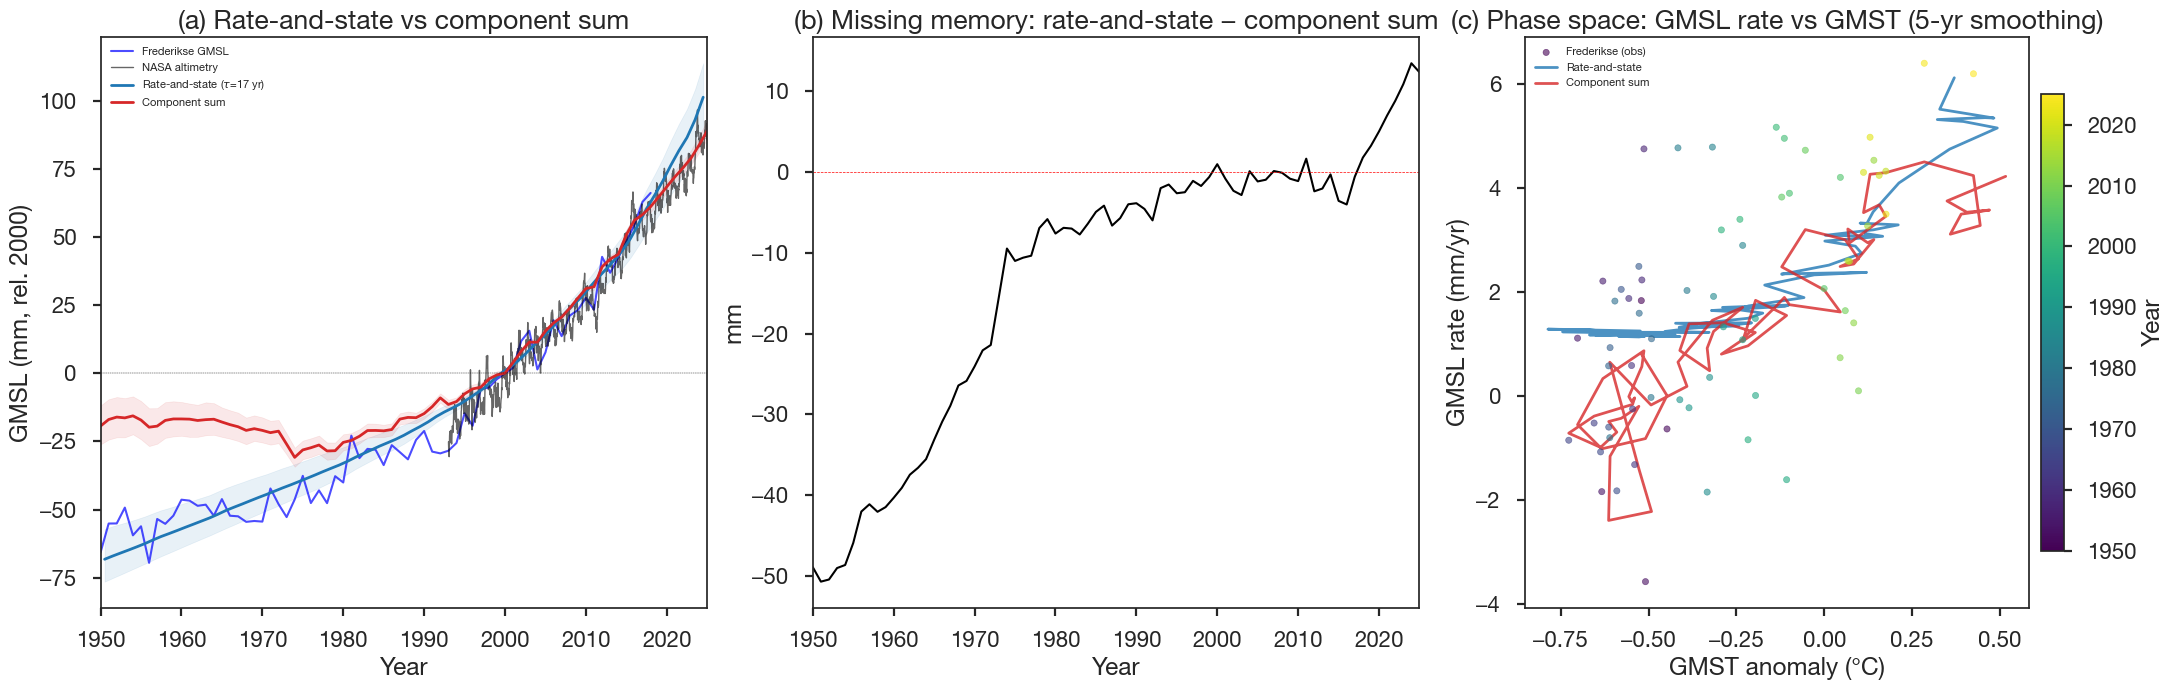


Residual (rate-and-state − component sum) at key years:
  1995: -2.7 mm
  2000: +0.9 mm
  2005: -1.2 mm
  2010: -1.2 mm
  2015: -3.6 mm
  2020: +5.0 mm

Mean absolute residual: 14.6 mm
Max absolute residual:  50.7 mm


In [7]:
# ── Diagnostic 7: Residual analysis — rate-and-state vs component sum ──
# Option 1: compare the rate-and-state GMSL hindcast (which fits the full
# observed GMSL well) against the component sum.  The residual reveals
# "missing memory" — slow response physics not captured by any single
# component model.
#
# Includes a phase-space plot: GMSL rate vs GMST.

# ── Load rate-and-state calibration ──
H5_RS = '../data/processed/bayesian_ratestate_posterior.h5'
with h5py.File(H5_RS, 'r') as _hf:
    coeffs_abcd = _hf['calibration/coefficients'][:]  # [a, b, c, d] in m/yr
    cov_abcd = _hf['calibration/covariance'][:]       # 4x4 covariance in m/yr
    _rs_r2 = float(_hf['calibration'].attrs['r_squared'])
    tau_samples_rs = _hf['posterior/tau'][:]

tau_median = float(np.median(tau_samples_rs))

# ── Run rate-and-state hindcast with observed GMST only ──
# Build a single "hindcast" scenario from Berkeley Earth annual GMST
mask_rs_hind = ((berk_annual['decimal_year'] >= HIND_START)
                & (berk_annual['decimal_year'] <= HIND_END))
df_rs_temp = berk_annual[mask_rs_hind][['temperature', 'decimal_year']].copy()

rs_hind = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples_rs,
    temperature_projections={'hindcast': df_rs_temp},
    historical_temperature=T_monthly,
    historical_time=t_monthly,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=N_MC,
    seed=42,
)

rs_df = rs_hind['scenarios']['hindcast']
rs_time = rs_df['decimal_year'].values
rs_gmsl = rs_df['gmsl'].values          # meters, median
rs_gmsl_lo = rs_df['gmsl_lower'].values
rs_gmsl_hi = rs_df['gmsl_upper'].values
print(f'Rate-and-state hindcast: {rs_time[0]:.0f}–{rs_time[-1]:.0f}, '
      f'tau={tau_median:.1f} yr')

# ── Compute residual: rate-and-state minus component sum ──
# Interpolate both onto common annual grid
rs_on_hind = np.interp(hind_years, rs_time, rs_gmsl)
residual_rs_comp = (rs_on_hind - total_med) * M_TO_MM  # mm

# ── Compute GMSL rates for phase-space plot ──
# Use centered finite differences on annual data for smoothed rates.
SMOOTH_WIN = 5  # years, for rate estimation

def _smooth_rate(time, level, win=SMOOTH_WIN):
    """Smoothed rate via linear fit in sliding window."""
    rates = np.full_like(time, np.nan)
    hw = win // 2
    for i in range(hw, len(time) - hw):
        c = polyfit(time[i-hw:i+hw+1], level[i-hw:i+hw+1], 1)
        rates[i] = c[1]
    return rates

# Observed GMSL rate (Frederikse annual)
fm_hind = (fred_year >= HIND_START) & (fred_year <= HIND_END)
fred_rate = _smooth_rate(fred_year[fm_hind], fred_gmsl[fm_hind]) * M_TO_MM
fred_T_annual = np.interp(fred_year[fm_hind], berk_annual['decimal_year'].values,
                          berk_annual['temperature'].values)

# Rate-and-state rate
rs_rate = _smooth_rate(rs_time, rs_gmsl) * M_TO_MM
rs_T = np.interp(rs_time, berk_annual['decimal_year'].values,
                 berk_annual['temperature'].values)

# Component sum rate
comp_rate = _smooth_rate(hind_years, total_med) * M_TO_MM
comp_T = np.interp(hind_years, berk_annual['decimal_year'].values,
                   berk_annual['temperature'].values)

# ── Plot: 3 panels ──
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel (a): Level comparison — rate-and-state vs component sum vs obs
ax = axes[0]
fm_plot = (fred_year >= HIND_START) & (fred_year <= HIND_END)
ax.plot(fred_year[fm_plot], fred_gmsl[fm_plot] * M_TO_MM,
        'b-', lw=1.5, alpha=0.7, label='Frederikse GMSL')
nm_plot = (nasa_time >= max(1993, HIND_START)) & (nasa_time <= HIND_END)
ax.plot(nasa_time[nm_plot], nasa_gmsl_rb[nm_plot] * M_TO_MM,
        'k-', lw=1, alpha=0.6, label='NASA altimetry')

ax.plot(rs_time, rs_gmsl * M_TO_MM, color='tab:blue', lw=2,
        label=f'Rate-and-state ($\\tau$={tau_median:.0f} yr)')
ax.fill_between(rs_time, rs_gmsl_lo * M_TO_MM, rs_gmsl_hi * M_TO_MM,
                color='tab:blue', alpha=0.1)
ax.plot(hind_years, total_med * M_TO_MM, color='tab:red', lw=2,
        label='Component sum')
ax.fill_between(hind_years, total_p17 * M_TO_MM, total_p83 * M_TO_MM,
                color='tab:red', alpha=0.1)

ax.set_xlim(HIND_START, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel(f'GMSL (mm, rel. {BASELINE_YEAR:.0f})')
ax.set_title('(a) Rate-and-state vs component sum')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=8, loc='upper left')

# Panel (b): Residual — rate-and-state minus component sum
ax = axes[1]
ax.plot(hind_years, residual_rs_comp, 'k-', lw=1.5)
ax.axhline(0, color='r', lw=0.5, ls='--')
ax.set_xlim(HIND_START, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel('mm')
ax.set_title('(b) Missing memory: rate-and-state − component sum')

# Panel (c): Phase-space — GMSL rate vs GMST
ax = axes[2]
# Observed (Frederikse) as scatter
valid_f = np.isfinite(fred_rate)
ax.scatter(fred_T_annual[valid_f], fred_rate[valid_f],
           c=fred_year[fm_hind][valid_f], cmap='viridis', s=20,
           alpha=0.6, zorder=3, label='Frederikse (obs)')

# Rate-and-state as blue line
valid_rs = np.isfinite(rs_rate)
ax.plot(rs_T[valid_rs], rs_rate[valid_rs],
        color='tab:blue', lw=2, alpha=0.8, label='Rate-and-state')

# Component sum as red line
valid_c = np.isfinite(comp_rate)
ax.plot(comp_T[valid_c], comp_rate[valid_c],
        color='tab:red', lw=2, alpha=0.8, label='Component sum')

ax.set_xlabel('GMST anomaly (°C)')
ax.set_ylabel('GMSL rate (mm/yr)')
ax.set_title(f'(c) Phase space: GMSL rate vs GMST ({SMOOTH_WIN}-yr smoothing)')
ax.legend(fontsize=8)

# Colorbar for year
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(HIND_START, HIND_END))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Year')

plt.tight_layout()
plt.show()

# ── Summary statistics ──
idx_2020 = np.argmin(np.abs(hind_years - 2020))
print(f'\nResidual (rate-and-state − component sum) at key years:')
for yr in [1995, 2000, 2005, 2010, 2015, 2020]:
    idx = np.argmin(np.abs(hind_years - yr))
    print(f'  {yr}: {residual_rs_comp[idx]:+.1f} mm')

print(f'\nMean absolute residual: {np.nanmean(np.abs(residual_rs_comp)):.1f} mm')
print(f'Max absolute residual:  {np.nanmax(np.abs(residual_rs_comp)):.1f} mm')

In [8]:
# ── Diagnostic 10: Budget residual attribution ──
# Decompose the residual (NASA GMSL minus component sum) across components
# in proportion to each component's variance. This is the Bayesian update
# under joint Gaussian assumptions WITHOUT modifying posteriors — purely
# diagnostic. Components with large uncertainty absorb more of the residual.
#
# shift_i(t) = [sigma_i(t)^2 / sum_j sigma_j(t)^2] * residual(t)

# ── Component MC samples on hind_years (from Diagnostic 6) ──
# ocean_samp_interp: (n, len(hind_years))  — stored hybrid NOAA+IPCC
# glacier_hind['samples']: (n, len(hind_years))
# eais_hind['samples']: (n, len(hind_years))
# apen_hind['samples']: (n, len(hind_years))
# gr_samples: (n, len(hind_years))  — stored Greenland (SMB+D)
# wais_samples: (n, len(hind_years))  — stored WAIS
# tws_samples: (n, len(hind_years))  — Frederikse TWS

budget_components = {
    'Thermosteric': ocean_samp_interp[:n],
    'Glaciers':     glacier_hind['samples'][:n],
    'Greenland':    gr_samples[:n],
    'EAIS':         eais_hind['samples'][:n],
    'Peninsula':    apen_hind['samples'][:n],
    'WAIS':         wais_samples[:n],
    'TWS':          tws_samples[:n],
}

# Variance of each component at each time point
comp_var = {name: np.var(samp, axis=0) for name, samp in budget_components.items()}
comp_med = {name: np.median(samp, axis=0) for name, samp in budget_components.items()}
total_var = sum(comp_var.values())  # sum of variances at each time

# Component sum median
comp_sum_med = sum(comp_med.values())

# Residual: NASA minus our component sum (on hind_years, satellite era only)
nasa_on_hind = np.interp(hind_years, nasa_time, nasa_gmsl_rb)
residual_hind = nasa_on_hind - comp_sum_med  # meters

# Variance fraction (weight) for each component
var_frac = {name: v / np.where(total_var > 0, total_var, 1.0)
            for name, v in comp_var.items()}

# Attributed shift for each component
comp_shift = {name: var_frac[name] * residual_hind for name in budget_components}

# ── Report at key years (satellite era) ──
report_years = [1993, 2000, 2005, 2010, 2020]
report_idx = [np.argmin(np.abs(hind_years - yr)) for yr in report_years]

print(f'Budget residual attribution (mm, rel. {BASELINE_YEAR:.0f})')
print(f'{"Component":<14}', end='')
for yr in report_years:
    print(f' {yr:>7}', end='')
print(f' {"var%":>7}')
print('-' * (14 + 8 * (len(report_years) + 1)))

# Mean variance fraction over satellite era for the summary column
sat_mask = (hind_years >= SAT_ERA_START) & (hind_years <= 2020)

for name in budget_components:
    print(f'{name:<14}', end='')
    for idx in report_idx:
        print(f' {comp_shift[name][idx]*M_TO_MM:7.1f}', end='')
    mean_vf = np.mean(var_frac[name][sat_mask]) * 100
    print(f' {mean_vf:6.1f}%')

print('-' * (14 + 8 * (len(report_years) + 1)))
print(f'{"Residual":<14}', end='')
for idx in report_idx:
    print(f' {residual_hind[idx]*M_TO_MM:7.1f}', end='')
print()

print(f'{"NASA GMSL":<14}', end='')
for idx in report_idx:
    print(f' {nasa_on_hind[idx]*M_TO_MM:7.1f}', end='')
print()

print(f'{"Our sum":<14}', end='')
for idx in report_idx:
    print(f' {comp_sum_med[idx]*M_TO_MM:7.1f}', end='')
print()

# ── Rate-space attribution (1993–2020 trend) ──
sat_yrs = hind_years[sat_mask]
c_resid = polyfit(sat_yrs, residual_hind[sat_mask] * M_TO_MM, 1)
print(f'\nResidual trend 1993–2020: {c_resid[1]:.2f} mm/yr')
print(f'\nRate-space attribution (mm/yr, 1993–2020):')
for name in budget_components:
    c_shift = polyfit(sat_yrs, comp_shift[name][sat_mask] * M_TO_MM, 1)
    c_comp = polyfit(sat_yrs, comp_med[name][sat_mask] * M_TO_MM, 1)
    mean_vf = np.mean(var_frac[name][sat_mask]) * 100
    print(f'  {name:<14} rate={c_comp[1]:+.2f}, '
          f'shift={c_shift[1]:+.2f} mm/yr ({mean_vf:.0f}% of variance)')

# ── Are the shifts within 1-sigma of each component? ──
print(f'\nShift vs 1-sigma at 2020:')
idx_2020 = np.argmin(np.abs(hind_years - 2020))
for name in budget_components:
    shift_mm = comp_shift[name][idx_2020] * M_TO_MM
    sigma_mm = np.sqrt(comp_var[name][idx_2020]) * M_TO_MM
    ratio = abs(shift_mm) / sigma_mm if sigma_mm > 0 else np.inf
    flag = '' if ratio < 1 else ' *' if ratio < 2 else ' **'
    print(f'  {name:<14} shift={shift_mm:+.1f} mm, '
          f'1σ={sigma_mm:.1f} mm, ratio={ratio:.2f}{flag}')


Budget residual attribution (mm, rel. 2000)
Component         1993    2000    2005    2010    2020    var%
--------------------------------------------------------------
Thermosteric      -1.4    -0.0    -0.3    -1.5    -0.7   30.6%
Glaciers          -0.1    -0.0    -0.0    -0.1    -0.0    1.3%
Greenland         -0.7    -0.0    -0.3    -0.6    -0.0   10.0%
EAIS              -0.0    -0.0    -0.0    -0.0    -0.0    0.8%
Peninsula         -0.0    -0.0    -0.0    -0.0    -0.0    0.1%
WAIS              -0.1    -0.1    -0.3    -0.6    -0.1   11.8%
TWS              -11.3    -0.8    -0.9    -0.0    -0.2   45.4%
--------------------------------------------------------------
Residual         -13.6    -0.8    -1.8    -2.9    -1.1
NASA GMSL        -25.1    -0.8    13.7    28.2    67.3
Our sum          -11.5     0.1    15.5    31.1    68.4

Residual trend 1993–2020: 0.07 mm/yr

Rate-space attribution (mm/yr, 1993–2020):
  Thermosteric   rate=+1.25, shift=-0.11 mm/yr (31% of variance)
  Glaciers    

## 4. Summary Table (2050, 2100, 2150)

In [9]:
# ── Summary table: per-component + total at milestone years ──
milestone_years = MILESTONE_YEARS

rows = []
for ssp in PROJ_SSPS:
    for yr in milestone_years:
        idx = np.argmin(np.abs(proj_years - yr))
        row = {'SSP': ssp, 'Year': yr}
        for cname in comp_order:
            if cname in comp_projections[ssp]:
                s = comp_projections[ssp][cname]['samples'][:, idx] * M_TO_MM
                row[cname] = f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]'
            else:
                row[cname] = '—'
        s_tot = comp_projections[ssp]['Total_sum']['samples'][:, idx] * M_TO_MM
        row['Total'] = f'{np.median(s_tot):.0f} [{np.percentile(s_tot, 5):.0f}, {np.percentile(s_tot, 95):.0f}]'
        rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['SSP', 'Year'])
display(df_summary)

Thermosteric        Glaciers       Greenland   Peninsula  \
SSP      Year                                                               
SSP1-2.6 2050    90 [78, 101]     46 [43, 48]     48 [39, 58]    3 [2, 4]   
         2100  140 [111, 176]  107 [100, 112]   123 [93, 153]   7 [4, 11]   
         2150  140 [111, 176]  107 [100, 112]  188 [139, 236]   7 [4, 11]   
SSP2-4.5 2050    99 [88, 111]     47 [45, 50]     51 [40, 61]    3 [2, 5]   
         2100  238 [200, 285]  128 [120, 136]  170 [123, 215]   9 [4, 15]   
         2150  238 [200, 285]  128 [120, 136]  299 [208, 389]   9 [4, 15]   
SSP3-7.0 2050   106 [94, 119]     48 [46, 51]     53 [42, 64]    3 [2, 5]   
         2100  365 [298, 441]  148 [138, 158]  219 [153, 284]  11 [4, 18]   
         2150  365 [298, 441]  148 [138, 158]  438 [287, 591]  11 [4, 18]   
SSP5-8.5 2050  119 [105, 137]     51 [48, 53]     58 [45, 70]    3 [2, 5]   
         2100  490 [381, 607]  167 [155, 179]  272 [184, 359]  12 [5, 21]   
         2150  490 [381, 607]  167 [155, 179]  566 [353, 781]  12 [5, 21]   

                          WAIS           TWS              Total  
SSP      Year                                                    
SSP1-2.6 2050     45 [15, 199]    9 [-1, 19]     243 [205, 404]  
         2100   410 [61, 1517]    29 [8, 50]    822 [469, 1936]  
         2150  1349 [96, 6522]   45 [16, 73]   1835 [579, 7056]  
SSP2-4.5 2050     45 [15, 199]    9 [-1, 19]     256 [218, 415]  
         2100   410 [61, 1517]    30 [7, 53]    994 [642, 2106]  
         2150  1349 [96, 6522]   51 [15, 85]   2069 [821, 7321]  
SSP3-7.0 2050     45 [15, 199]    9 [-1, 19]     266 [226, 424]  
         2100   410 [61, 1517]    35 [9, 61]   1199 [843, 2313]  
         2150  1349 [96, 6522]  67 [21, 111]  2371 [1133, 7628]  
SSP5-8.5 2050     45 [15, 199]    9 [-1, 19]     289 [245, 444]  
         2100   410 [61, 1517]    29 [8, 50]  1397 [1026, 2530]  
         2150  1349 [96, 6522]   46 [16, 75]  2625 [1388, 7860]

## 5. Projection Fan Plots

In [10]:
# ── Satellite-era quadratic fit (Hamlington method) ──
ABLAIN_COV_PATH = f'{RAW_DIR}/gmslr/ablain2019_gmsl_error_covariance.nc'

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time, gmsl=nasa_gmsl, sigma=None,
    t_start=SAT_ERA_START, t_end=nasa_time[-1],
    eval_time=nasa_time[-1],
    meas_cov_path=ABLAIN_COV_PATH if os.path.exists(ABLAIN_COV_PATH) else None,
)

# Extrapolate to 2150, rebase to BASELINE_YEAR
sat_quad_time = np.arange(int(SAT_ERA_START), 2151, dtype=float)
_dt = sat_quad_time - sat_quad.t_start
sat_quad_fit = (sat_quad.coefficients[0]
                + sat_quad.coefficients[1] * _dt
                + sat_quad.coefficients[2] * _dt**2)
_sq_at_bl = np.interp(BASELINE_YEAR, sat_quad_time, sat_quad_fit)
sat_quad_fit_rb = sat_quad_fit - _sq_at_bl

# MC CI from parameter covariance
rng_sq = np.random.default_rng(42)
_n_mc_sq = 10_000
_sq_samples = rng_sq.multivariate_normal(
    sat_quad.coefficients, sat_quad.cov_params, size=_n_mc_sq)
_sq_boot = np.zeros((_n_mc_sq, len(sat_quad_time)))
for k in range(_n_mc_sq):
    _sq_boot[k] = (_sq_samples[k, 0]
                    + _sq_samples[k, 1] * _dt
                    + _sq_samples[k, 2] * _dt**2)
_sq_boot_rb = _sq_boot - _sq_at_bl
sat_quad_p5  = np.percentile(_sq_boot_rb, 5, axis=0)
sat_quad_p17 = np.percentile(_sq_boot_rb, 17, axis=0)
sat_quad_p83 = np.percentile(_sq_boot_rb, 83, axis=0)
sat_quad_p95 = np.percentile(_sq_boot_rb, 95, axis=0)
del _sq_boot, _sq_boot_rb, _sq_samples

# ── Load IPCC AR6 total projections ──
ipcc_total = {}
for ssp, code in SSP_TO_CODE.items():
    data = read_ipcc_component_nc(CONF_BASE, IPCC_CONFIDENCE, code, 'total')
    if data is not None:
        ipcc_total[ssp] = data

print(f'Satellite-era quadratic fit:')
print(f'  Window: {sat_quad.t_start:.0f}–{sat_quad.t_end:.1f}, n={sat_quad.n_obs}')
print(f'  Rate at {sat_quad.eval_time:.1f}: {sat_quad.rate*M_TO_MM:.2f} mm/yr')
print(f'  Accel: {sat_quad.accel*1e6:.1f} um/yr^2')
for yr in [2050, 2100, 2150]:
    v = np.interp(yr, sat_quad_time, sat_quad_fit_rb)
    lo = np.interp(yr, sat_quad_time, sat_quad_p5)
    hi = np.interp(yr, sat_quad_time, sat_quad_p95)
    print(f'  {yr}: {v*M_TO_MM:.0f} [{lo*M_TO_MM:.0f}, {hi*M_TO_MM:.0f}] mm')
print(f'\nNASA GMSL: {nasa_time[0]:.1f}\u2013{nasa_time[-1]:.1f} (rebased to {BASELINE_YEAR:.0f})')
# IPCC projections are relative to 1995–2014 mean; compute offset to our baseline
_ipcc_ref_center = 0.5 * (IPCC_REF_PERIOD[0] + IPCC_REF_PERIOD[1])  # ~2004.5
_gmsl_at_bl = np.interp(BASELINE_YEAR, nasa_time, nasa_gmsl)
_gmsl_at_ipcc_ref = np.interp(_ipcc_ref_center, nasa_time, nasa_gmsl)
ipcc_offset_mm = (_gmsl_at_bl - _gmsl_at_ipcc_ref) * M_TO_MM  # mm to add to IPCC

print(f'IPCC total loaded: {sorted(ipcc_total.keys())}')
print(f'IPCC baseline offset (year {BASELINE_YEAR:.0f} vs 1995–2014 mean): {ipcc_offset_mm:.1f} mm')

Satellite-era quadratic fit:
  Window: 1993–2025.3, n=1191
  Rate at 2025.3: 4.49 mm/yr
  Accel: 72.8 um/yr^2
  2050: 223 [175, 271] mm
  2100: 629 [380, 870] mm
  2150: 1217 [612, 1800] mm

NASA GMSL: 1993.0–2025.3 (rebased to 2000)
IPCC total loaded: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
IPCC baseline offset (year 2000 vs 1995–2014 mean): -11.1 mm


In [11]:
# ── Bayesian rate-and-state DOLS projection ──
# coeffs_abcd, cov_abcd, tau_samples_rs loaded in cell above (from H5_RS)

# Load Berkeley Earth monthly temperature + SSP projections
with pd.HDFStore(H5_OBS, 'r') as store:
    df_berkeley = store['/harmonized/df_berkeley_h']
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    temp_projections = {}
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# Annual temperature for merging with IPCC projections
temp_annual = df_berkeley[['temperature']].resample('YS').mean()
temp_annual['year'] = temp_annual.index.year + 0.5

# Build full temperature scenarios: historical + IPCC, in Berkeley Earth baseline
full_temp_scenarios = {}
for ssp_name, df_tp in temp_projections.items():
    df_cal = df_tp.copy()
    ipcc_first_year = df_cal['decimal_year'].iloc[0]
    idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_ov = temp_annual['temperature'].iloc[idx_ov]
    ipcc_ov = df_cal['temperature'].iloc[0]
    cal_offset = ipcc_ov - berk_ov
    df_cal['temperature'] = df_cal['temperature'] - cal_offset

    temp_annual_for_proj = temp_annual[['temperature']].copy()
    temp_annual_for_proj['decimal_year'] = temp_annual['year'].values
    hist = temp_annual_for_proj[
        temp_annual_for_proj['decimal_year'] < df_cal['decimal_year'].iloc[0]
    ].copy()
    proj = df_cal[['temperature', 'decimal_year']].copy()
    combined = pd.concat([hist, proj], ignore_index=False)
    combined = combined.sort_values('decimal_year').reset_index(drop=True)
    combined.index = pd.to_datetime(
        combined['decimal_year'].astype(int).astype(str) + '-01-01'
    )
    full_temp_scenarios[ssp_name] = combined

# Select from BASELINE_YEAR onward for projection grid
temp_proj_from_bl = {}
for ssp_name, combined in full_temp_scenarios.items():
    mask = combined['decimal_year'] >= BASELINE_YEAR
    temp_proj_from_bl[ssp_name] = combined[mask].copy()

# Run rate-and-state ensemble
rs_results = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples_rs,
    temperature_projections=temp_proj_from_bl,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    seed=42,
)

print('Rate-and-state projections computed for:', list(rs_results['scenarios'].keys()))
print(f'  tau median: {tau_median:.1f} yr')
for ssp in PROJ_SSPS:
    rs_df = rs_results['scenarios'][ssp]
    idx_2100 = np.argmin(np.abs(rs_df['decimal_year'].values - 2100))
    med = rs_df['gmsl'].values[idx_2100] * M_TO_MM
    lo = rs_df['gmsl_lower'].values[idx_2100] * M_TO_MM
    hi = rs_df['gmsl_upper'].values[idx_2100] * M_TO_MM
    print(f'  {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Rate-and-state projections computed for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  tau median: 17.0 yr
  SSP1-2.6 at 2100: 828 [684, 962] mm
  SSP2-4.5 at 2100: 1356 [1086, 1611] mm
  SSP3-7.0 at 2100: 2052 [1604, 2482] mm
  SSP5-8.5 at 2100: 2832 [2178, 3459] mm


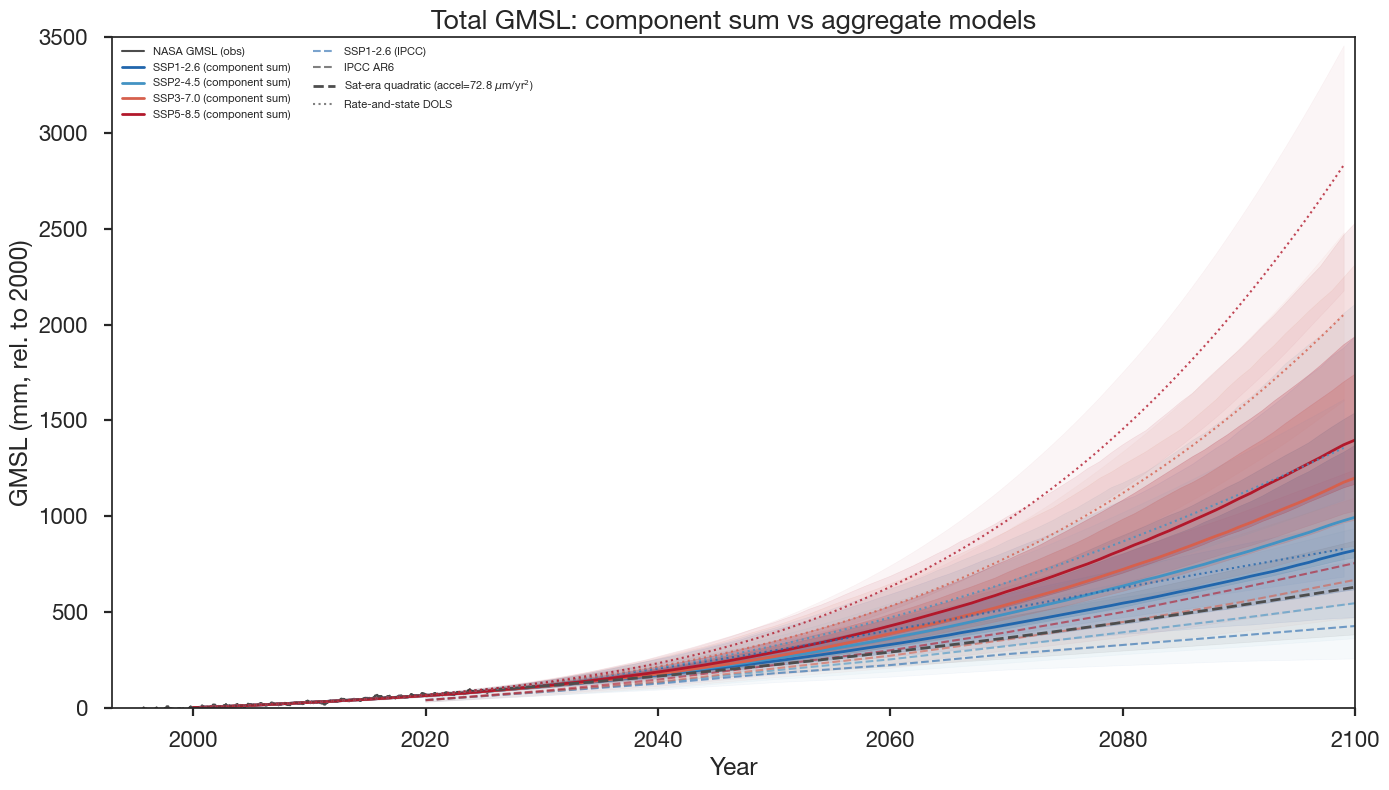

In [12]:
# ── Total GMSL projection: all SSPs + quad fit + rate-and-state ──

# ====== SWITCHES ======
SHOW_OBS        = True   # NASA GMSL observations
SHOW_QUAD       = True   # Satellite-era quadratic extrapolation
SHOW_RS         = True   # Rate-and-state DOLS
SHOW_IPCC       = True   # IPCC AR6 total projections
SHOW_COMP_SUM   = True   # Component sum
YEAR_END        = 2100   # right edge of x-axis
# ======================

proj_mask = proj_years >= BASELINE_YEAR
yr_plot = proj_years[proj_mask]

fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
if SHOW_OBS:
    obs_mask = nasa_time >= SAT_ERA_START
    ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
            'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Component sum (per SSP) ---
if SHOW_COMP_SUM:
    for ssp in PROJ_SSPS:
        p = comp_projections[ssp]['Total_sum']
        med = p['median'][proj_mask] * M_TO_MM
        lo17 = p['p17'][proj_mask] * M_TO_MM
        hi83 = p['p83'][proj_mask] * M_TO_MM
        lo5 = p['p5'][proj_mask] * M_TO_MM
        hi95 = p['p95'][proj_mask] * M_TO_MM
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (component sum)')
        ax.fill_between(yr_plot, lo17, hi83, color=color, alpha=0.20)
        ax.fill_between(yr_plot, lo5, hi95, color=color, alpha=0.08)

# --- IPCC AR6 total ---
if SHOW_IPCC:
    for ssp in PROJ_SSPS:
        if ssp in ipcc_total:
            ie = ipcc_extract(ipcc_total[ssp])
            color = SSP_COLORS.get(ssp, 'gray')
            ax.plot(ie['years'], ie['q50'] + ipcc_offset_mm, color=color, lw=1.5, ls='--', alpha=0.6,
                    label=f'{ssp} (IPCC)' if ssp == PROJ_SSPS[0] else '')
            ax.fill_between(ie['years'], ie['q05'] + ipcc_offset_mm, ie['q95'] + ipcc_offset_mm,
                            color=color, alpha=0.04)
    ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6')

# --- Satellite-era quadratic extrapolation ---
if SHOW_QUAD:
    sq_obs_mask = (sat_quad_time >= BASELINE_YEAR) & (sat_quad_time <= nasa_time[-1])
    ax.plot(sat_quad_time[sq_obs_mask], sat_quad_fit_rb[sq_obs_mask] * M_TO_MM,
            '-', color='0.3', lw=1, alpha=0.6)
    sq_ext_mask = sat_quad_time >= nasa_time[-1]
    ax.plot(sat_quad_time[sq_ext_mask], sat_quad_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='0.3', lw=2,
            label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
    ax.fill_between(sat_quad_time[sq_ext_mask],
                    sat_quad_p5[sq_ext_mask] * M_TO_MM,
                    sat_quad_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Rate-and-state DOLS (per SSP) ---
if SHOW_RS:
    for ssp in PROJ_SSPS:
        rs_df = rs_results['scenarios'][ssp]
        rs_time = rs_df['decimal_year'].values
        mask_rs = (rs_time >= BASELINE_YEAR) & (rs_time <= YEAR_END)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs] * M_TO_MM,
                ':', color=color, lw=1.5, alpha=0.8)
        ax.fill_between(rs_time[mask_rs],
                        rs_df['gmsl_lower'].values[mask_rs] * M_TO_MM,
                        rs_df['gmsl_upper'].values[mask_rs] * M_TO_MM,
                        color=color, alpha=0.04)
    ax.plot([], [], ':', color='0.5', lw=1.5, label='Rate-and-state DOLS')

ax.set_ylim(0,3500)

ax.set_xlabel('Year')
ax.set_ylabel(f'GMSL (mm, rel. to {BASELINE_YEAR:.0f})')
ax.set_title('Total GMSL: component sum vs aggregate models')
ax.set_xlim(int(SAT_ERA_START) if SHOW_OBS else int(BASELINE_YEAR), YEAR_END)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_total.png', dpi=150, bbox_inches='tight')
plt.show()

  IPCC excl. AIS SSP1-2.6 at 2100: 315 [140, 536] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP2-4.5 at 2100: 433 [240, 675] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP3-7.0 at 2100: 555 [340, 812] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP5-8.5 at 2100: 632 [404, 930] mm (Thermosteric, Glaciers, Greenland, TWS)


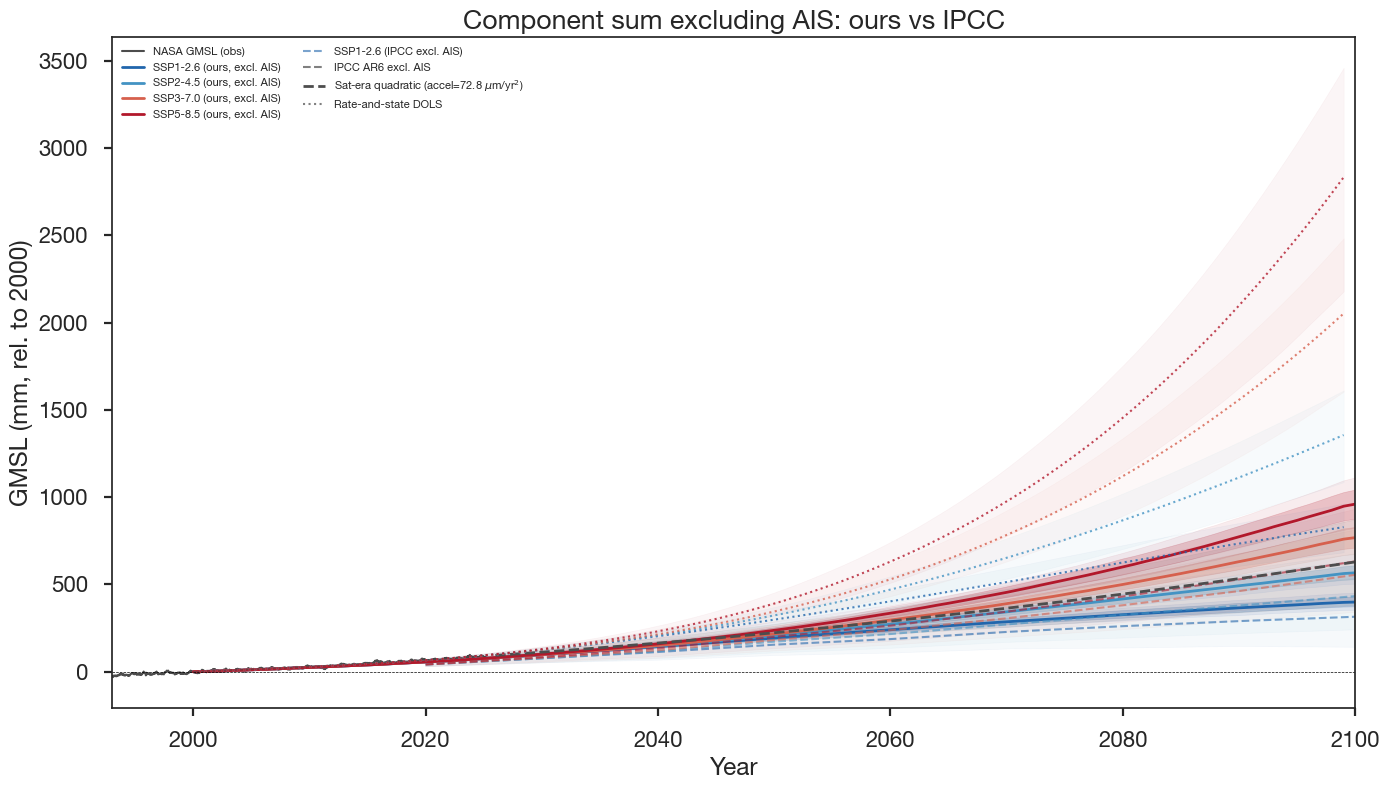

In [13]:
# ── Total GMSL excluding AIS: component-level comparison with IPCC ──
# Remove all Antarctic components (EAIS, WAIS, Peninsula) from both
# our sum and the IPCC sum for a like-for-like comparison.

# ====== SWITCHES ======
SHOW_OBS_NA     = True   # NASA GMSL observations
SHOW_QUAD_NA    = True   # Satellite-era quadratic extrapolation
SHOW_RS_NA      = True   # Rate-and-state DOLS
SHOW_IPCC_NA    = True   # IPCC component sum (excl. AIS)
SHOW_COMP_NA    = True   # Our component sum (excl. AIS)
YEAR_END_NA     = 2100   # right edge of x-axis
# ======================

ais_labels = {'EAIS', 'WAIS', 'Peninsula'}
comps_no_ais = [c for c in COMP_LABELS.values() if c not in ais_labels]

# Load IPCC components for like-for-like sum (excl. AIS)
ipcc_comp_map = {
    'oceandynamics': 'Thermosteric',
    'glaciers': 'Glaciers',
    'GIS': 'Greenland',
    'landwaterstorage': 'TWS',
}

ipcc_no_ais = {}  # {ssp: {'years': ..., 'q50': ..., 'q05': ..., 'q95': ...}}
for ssp, code in SSP_TO_CODE.items():
    comp_data = {}
    for ipcc_key, label in ipcc_comp_map.items():
        data = read_ipcc_component_nc(CONF_BASE, IPCC_CONFIDENCE, code, ipcc_key)
        if data is not None:
            comp_data[label] = ipcc_extract(data)

    if not comp_data:
        continue

    # Sum on common year grid (use first component's years)
    ref_years = list(comp_data.values())[0]['years']
    q50_sum = np.zeros_like(ref_years, dtype=float)
    q05_sum = np.zeros_like(ref_years, dtype=float)
    q95_sum = np.zeros_like(ref_years, dtype=float)
    for label, ie in comp_data.items():
        q50_sum += np.interp(ref_years, ie['years'], ie['q50'])
        q05_sum += np.interp(ref_years, ie['years'], ie['q05'])
        q95_sum += np.interp(ref_years, ie['years'], ie['q95'])

    ipcc_no_ais[ssp] = {'years': ref_years, 'q50': q50_sum,
                         'q05': q05_sum, 'q95': q95_sum}

    idx_2100 = np.argmin(np.abs(ref_years - 2100))
    print(f'  IPCC excl. AIS {ssp} at 2100: {q50_sum[idx_2100]:.0f} '
          f'[{q05_sum[idx_2100]:.0f}, {q95_sum[idx_2100]:.0f}] mm '
          f'({", ".join(comp_data.keys())})')

fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
if SHOW_OBS_NA:
    obs_mask = nasa_time >= SAT_ERA_START
    ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
            'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Our component sum excluding AIS ---
if SHOW_COMP_NA:
    for ssp in PROJ_SSPS:
        total_no_ais = np.zeros_like(
            comp_projections[ssp]['Total_sum']['samples'])
        for cname in comps_no_ais:
            if cname in comp_projections[ssp]:
                total_no_ais += comp_projections[ssp][cname]['samples']

        med = np.median(total_no_ais, axis=0)[proj_mask] * M_TO_MM
        lo17 = np.percentile(total_no_ais, 17, axis=0)[proj_mask] * M_TO_MM
        hi83 = np.percentile(total_no_ais, 83, axis=0)[proj_mask] * M_TO_MM
        lo5 = np.percentile(total_no_ais, 5, axis=0)[proj_mask] * M_TO_MM
        hi95 = np.percentile(total_no_ais, 95, axis=0)[proj_mask] * M_TO_MM
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (ours, excl. AIS)')
        ax.fill_between(yr_plot, lo17, hi83, color=color, alpha=0.20)
        ax.fill_between(yr_plot, lo5, hi95, color=color, alpha=0.08)

# --- IPCC component sum excluding AIS ---
if SHOW_IPCC_NA:
    for ssp in PROJ_SSPS:
        if ssp in ipcc_no_ais:
            d = ipcc_no_ais[ssp]
            color = SSP_COLORS.get(ssp, 'gray')
            ax.plot(d['years'], d['q50'], color=color, lw=1.5, ls='--', alpha=0.6,
                    label=f'{ssp} (IPCC excl. AIS)' if ssp == PROJ_SSPS[0] else '')
            ax.fill_between(d['years'], d['q05'], d['q95'],
                            color=color, alpha=0.04)
    ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6 excl. AIS')

# --- Satellite-era quadratic extrapolation ---
if SHOW_QUAD_NA:
    sq_obs_mask = (sat_quad_time >= BASELINE_YEAR) & (sat_quad_time <= nasa_time[-1])
    ax.plot(sat_quad_time[sq_obs_mask], sat_quad_fit_rb[sq_obs_mask] * M_TO_MM,
            '-', color='0.3', lw=1, alpha=0.6)
    sq_ext_mask = sat_quad_time >= nasa_time[-1]
    ax.plot(sat_quad_time[sq_ext_mask], sat_quad_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='0.3', lw=2,
            label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
    ax.fill_between(sat_quad_time[sq_ext_mask],
                    sat_quad_p5[sq_ext_mask] * M_TO_MM,
                    sat_quad_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Rate-and-state DOLS ---
if SHOW_RS_NA:
    for ssp in PROJ_SSPS:
        rs_df = rs_results['scenarios'][ssp]
        rs_time = rs_df['decimal_year'].values
        mask_rs = (rs_time >= BASELINE_YEAR) & (rs_time <= YEAR_END_NA)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs] * M_TO_MM,
                ':', color=color, lw=1.5, alpha=0.8)
        ax.fill_between(rs_time[mask_rs],
                        rs_df['gmsl_lower'].values[mask_rs] * M_TO_MM,
                        rs_df['gmsl_upper'].values[mask_rs] * M_TO_MM,
                        color=color, alpha=0.04)
    ax.plot([], [], ':', color='0.5', lw=1.5, label='Rate-and-state DOLS')

ax.set_xlabel('Year')
ax.set_ylabel(f'GMSL (mm, rel. to {BASELINE_YEAR:.0f})')
ax.set_title('Component sum excluding AIS: ours vs IPCC')
ax.set_xlim(int(SAT_ERA_START) if SHOW_OBS_NA else int(BASELINE_YEAR), YEAR_END_NA)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_no_ais.png', dpi=150, bbox_inches='tight')
plt.show()

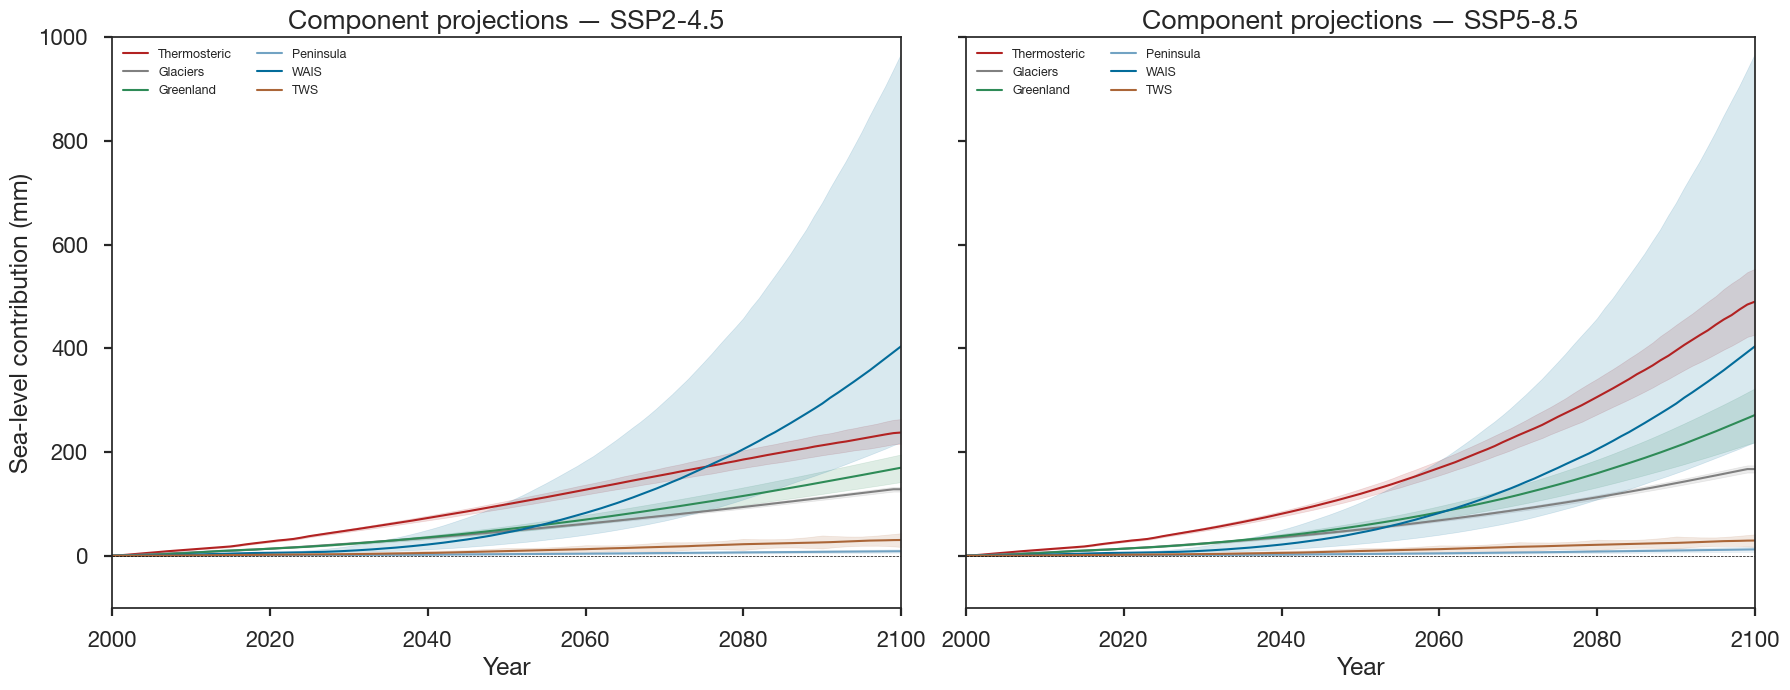

In [14]:
# ── Per-component fans for SSP2-4.5 and SSP5-8.5 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, ssp in zip(axes, ['SSP2-4.5', 'SSP5-8.5']):
    for cname in comp_order:
        if cname not in comp_projections[ssp]:
            continue
        p = comp_projections[ssp][cname]
        med = p['median'][proj_mask] * M_TO_MM
        lo = p['p17'][proj_mask] * M_TO_MM
        hi = p['p83'][proj_mask] * M_TO_MM
        color = COMP_COLORS.get(cname, 'gray')
        ax.plot(yr_plot, med, color=color, lw=1.5, label=cname)
        ax.fill_between(yr_plot, lo, hi, color=color, alpha=0.15)

    ax.set_xlabel('Year')
    ax.set_title(f'Component projections — {ssp}')
    ax.set_xlim(2000, 2100)
    ax.set_ylim(-100,1000)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.legend(fontsize=9, loc='upper left', ncol=2)

axes[0].set_ylabel('Sea-level contribution (mm)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_fans.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Component Stack & Variance Decomposition

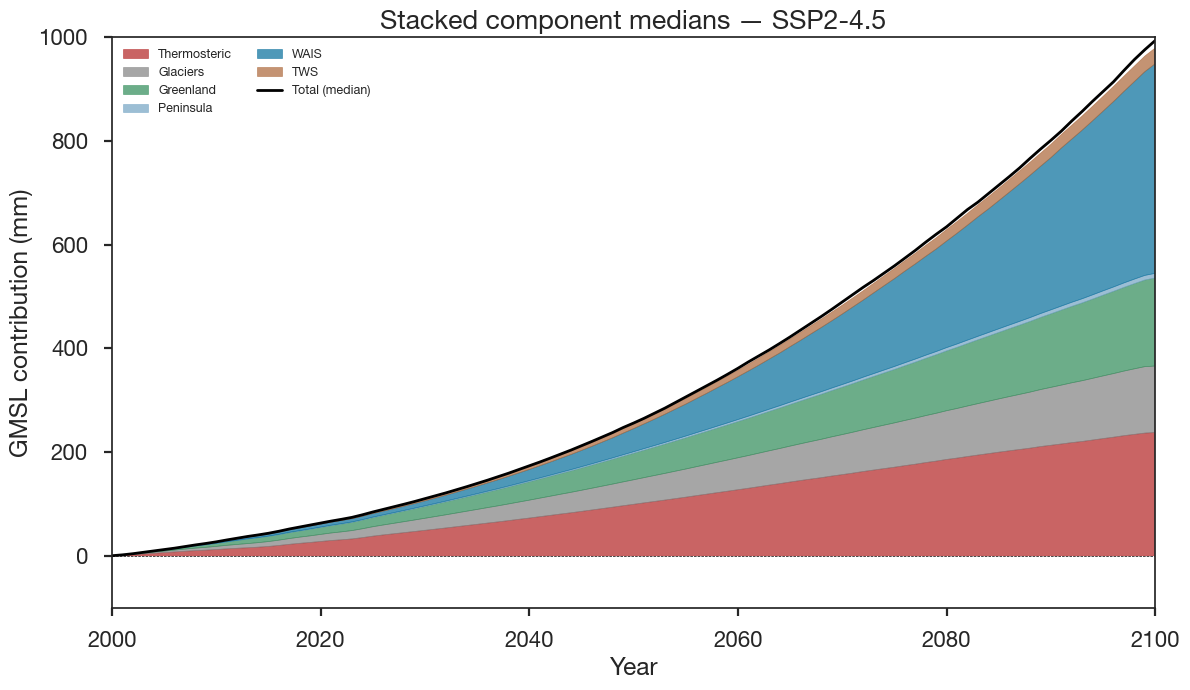

In [15]:
# ── Stacked median contributions (SSP2-4.5) ──
ssp_show = 'SSP2-4.5'
fig, ax = plt.subplots(figsize=(12, 7))

bottoms = np.zeros(proj_mask.sum())
for cname in comp_order:
    if cname not in comp_projections[ssp_show]:
        continue
    med = comp_projections[ssp_show][cname]['median'][proj_mask] * M_TO_MM
    color = COMP_COLORS.get(cname, 'gray')
    ax.fill_between(yr_plot, bottoms, bottoms + med, color=color, alpha=0.7, label=cname)
    bottoms += med

# Overlay total median
tot_med = comp_projections[ssp_show]['Total_sum']['median'][proj_mask] * M_TO_MM
ax.plot(yr_plot, tot_med, 'k-', lw=2, label='Total (median)')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL contribution (mm)')
ax.set_title(f'Stacked component medians — {ssp_show}')
ax.set_xlim(2000, 2100)
ax.set_ylim(-100,1000)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

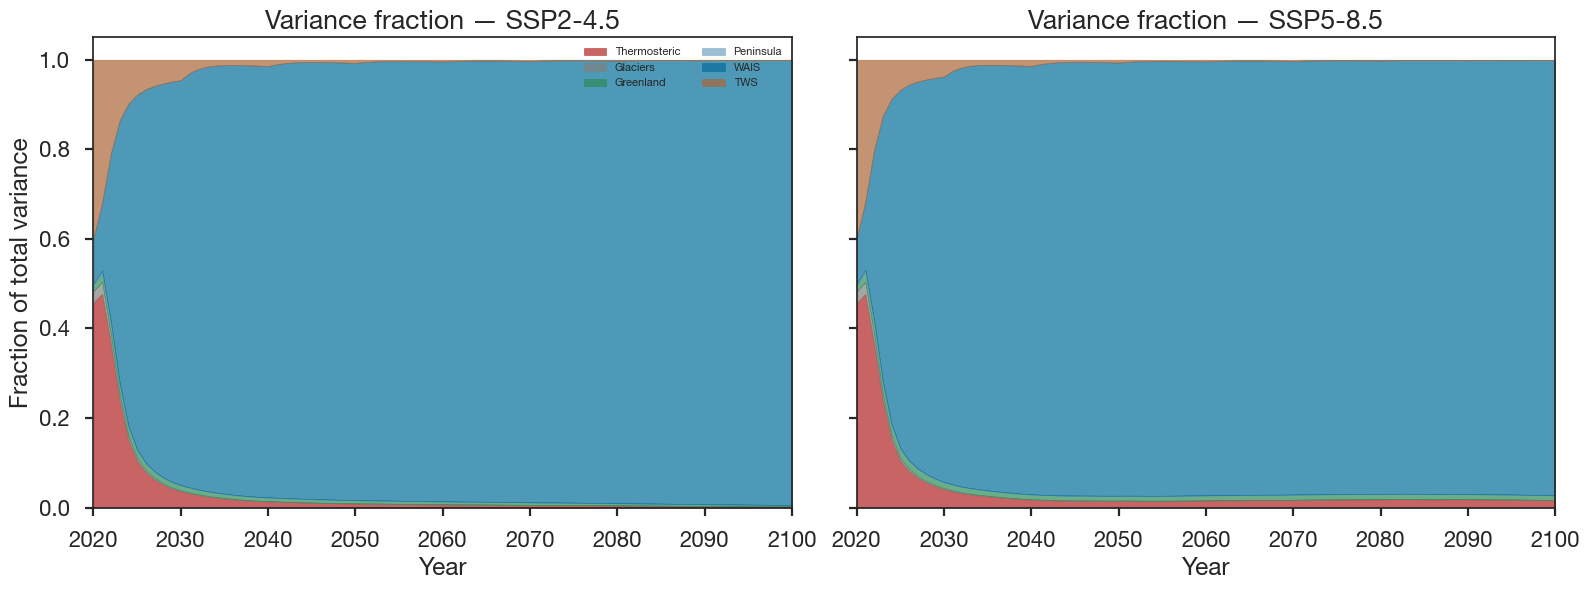

In [16]:
# ── Variance decomposition ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, ssp in zip(axes, ['SSP2-4.5', 'SSP5-8.5']):
    comps_available = [c for c in comp_order if c in comp_projections[ssp]]
    fracs, raw_sum = compute_variance_fractions(
        ssp, comps_available, proj_years, comp_projections,
    )
    proj_mask_var = proj_years >= 2020
    yr_var = proj_years[proj_mask_var]

    bottoms = np.zeros(proj_mask_var.sum())
    for cname in comps_available:
        f = fracs[cname][proj_mask_var]
        color = COMP_COLORS.get(cname, 'gray')
        ax.fill_between(yr_var, bottoms, bottoms + f, color=color, alpha=0.7, label=cname)
        bottoms += f

    ax.set_xlim(2020, 2100)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Year')
    ax.set_title(f'Variance fraction — {ssp}')

axes[0].set_ylabel('Fraction of total variance')
axes[0].legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. IPCC AR6 Comparison

In [17]:
# IPCC total (loaded alongside the satellite-era quadratic fit in §4)
for ssp in sorted(ipcc_total.keys()):
    data = ipcc_total[ssp]
    print(f'  {ssp}: {data["years"][0]:.0f}–{data["years"][-1]:.0f}, '
          f'{len(data["quantiles"])} quantiles')

  SSP1-2.6: 2020–2150, 107 quantiles
  SSP2-4.5: 2020–2150, 107 quantiles
  SSP3-7.0: 2020–2150, 107 quantiles
  SSP5-8.5: 2020–2150, 107 quantiles


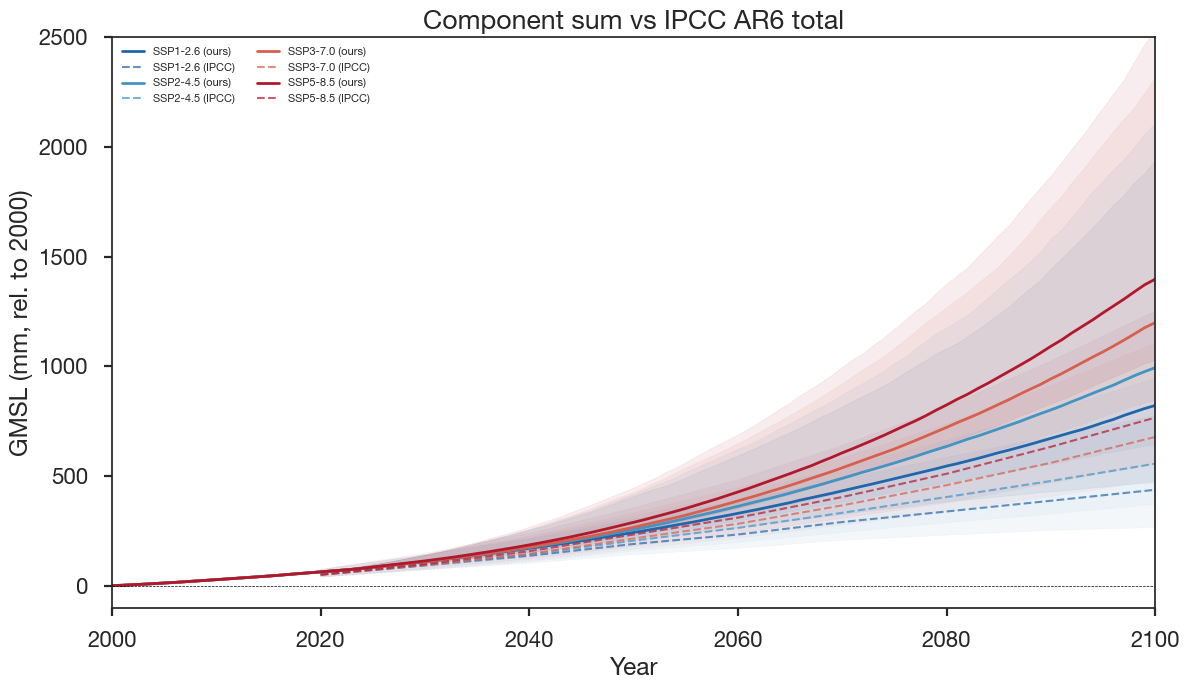

In [18]:
# ── Our total vs IPCC total ──
fig, ax = plt.subplots(figsize=(12, 7))

for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')

    # Our projection
    p = comp_projections[ssp]['Total_sum']
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (ours)')
    ax.fill_between(yr_plot, lo, hi, color=color, alpha=0.08)

    # IPCC
    if ssp in ipcc_total:
        ipcc_d = ipcc_total[ssp]
        ie = ipcc_extract(ipcc_d)
        ax.plot(ie['years'], ie['q50'], color=color, lw=1.5, ls='--', alpha=0.7,
                label=f'{ssp} (IPCC)')
        ax.fill_between(ie['years'], ie['q05'], ie['q95'],
                         color=color, alpha=0.05, linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel(f'GMSL (mm, rel. to {BASELINE_YEAR:.0f})')
ax.set_title('Component sum vs IPCC AR6 total')
ax.set_xlim(2000, 2100)
ax.set_ylim(-100,2500)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_vs_ipcc.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Numerical comparison at 2100 ──
print(f'{"SSP":<12} {"Ours (median [5,95])":<30} {"IPCC (median [5,95])":<30}')
print('-' * 72)
for ssp in PROJ_SSPS:
    idx_2100 = np.argmin(np.abs(proj_years - 2100))
    s = comp_projections[ssp]['Total_sum']['samples'][:, idx_2100] * M_TO_MM
    ours_str = f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]'

    if ssp in ipcc_total:
        ipcc_stats = get_ipcc_stats(
            {ssp: {'total': ipcc_total[ssp]}}, ssp, 'total', year=2100,
        )
        if ipcc_stats is not None:
            ipcc_str = f'{ipcc_stats[1]:.0f} [{ipcc_stats[0]:.0f}, {ipcc_stats[2]:.0f}]'
        else:
            ipcc_str = '—'
    else:
        ipcc_str = '—'

    print(f'{ssp:<12} {ours_str:<30} {ipcc_str:<30}')

SSP          Ours (median [5,95])           IPCC (median [5,95])          
------------------------------------------------------------------------
SSP1-2.6     822 [469, 1936]                437 [265, 775]                
SSP2-4.5     994 [642, 2106]                556 [371, 946]                
SSP3-7.0     1199 [843, 2313]               678 [480, 1105]               
SSP5-8.5     1397 [1026, 2530]              766 [555, 1252]               
